In [100]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

In [87]:
import matplotlib.pyplot as plt

# 1. Define your base font size
base_size = 12

# 2. Update matplotlib's global configurations (rcParams)
plt.rcParams.update({
    # Font Sizes
    'font.size': base_size,             # Default text size
    'axes.titlesize': base_size + 2,     # Title of subplots
    'axes.labelsize': base_size,         # X and Y axis labels
    'xtick.labelsize': base_size - 2,    # X-axis tick labels
    'ytick.labelsize': base_size - 2,    # Y-axis tick labels
    'legend.fontsize': base_size - 1,    # Legend text size
    'figure.titlesize': base_size + 4,   # Figure main title
    
    # Figure properties (Optional but highly recommended for consistency)
    'figure.figsize': (10, 5),           # Default width and height of figures in inches
    'figure.dpi': 100,                   # Screen resolution/crispness of figures
    'savefig.dpi': 300,                  # Resolution when saving plots
    'axes.grid': True,                   # Enable grids by default
    'grid.alpha': 0.3,                   # Make the grid lines subtle and light
    'grid.linestyle': '--'               # Dashed grid lines
})

# Part 1

## Task 1

In [88]:
np.random.seed(42)  # for reproducibility
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
], dtype=float)

n_women = 1000
X0 = 0        
n_states = P.shape[0]
DEAD = n_states - 1  

def sim_cancer_markov_until_all_dead(P, n_women, X0=0):
    current = np.full(n_women, X0, dtype=int)
    history = [current.copy()]

    while not np.all(current == DEAD):
        next_state = np.array([
            np.random.choice(P.shape[0], p=P[current[w]])
            for w in range(n_women)
        ])
        # Once dead, stay dead
        current = np.where(current == DEAD, DEAD, next_state)
        history.append(current.copy())

    return np.array(history).T  # shape: (n_women, T+1)

states_over_time = sim_cancer_markov_until_all_dead(P, n_women, X0)
T = states_over_time.shape[1] - 1
print(f"All {n_women} women reached Dead state after {T} time steps.")


All 1000 women reached Dead state after 1296 time steps.


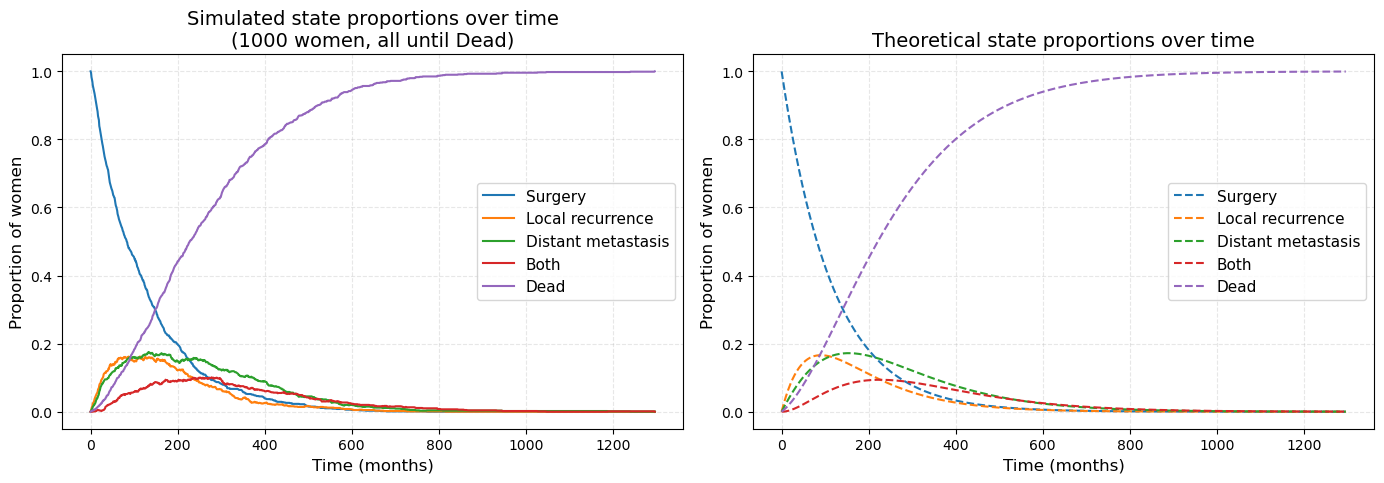

In [89]:
np.random.seed(42)  
state_labels = ["Surgery", "Local recurrence", "Distant metastasis", "Both", "Dead"]

# Simulated proportions: fraction of women in each state at each time step
proportions = np.zeros((T + 1, n_states))
for t in range(T + 1):
    for s in range(n_states):
        proportions[t, s] = np.sum(states_over_time[:, t] == s) / n_women

# Theoretical proportions via matrix power: pi(t) = pi(0) @ P^t (from project beskrivelse)
pi = np.zeros((T + 1, n_states))
pi[0, X0] = 1.0
Pt = np.eye(n_states)
for t in range(1, T + 1):
    Pt = Pt @ P
    pi[t] = pi[0] @ Pt

time = np.arange(T + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for s in range(n_states):
    axes[0].plot(time, proportions[:, s], label=state_labels[s])
axes[0].set_title(f"Simulated state proportions over time\n({n_women} women, all until Dead)")
axes[0].set_xlabel("Time (months)")
axes[0].set_ylabel("Proportion of women")
axes[0].legend(loc="center right")
axes[0].grid(True, alpha=0.3)

for s in range(n_states):
    axes[1].plot(time, pi[:, s], linestyle="--", label=state_labels[s])
axes[1].set_title("Theoretical state proportions over time")
axes[1].set_xlabel("Time (months)")
axes[1].set_ylabel("Proportion of women")
axes[1].legend(loc="center right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [90]:
# Proportion of women who ever enter state 1 (local recurrence)
ever_local = np.any((states_over_time == 1) | (states_over_time == 3), axis=1)
prob_local_recurrence = ever_local.mean() * 100
print(f"Proportion of women where cancer eventually reappears locally: {prob_local_recurrence:.2f}%")


Proportion of women where cancer eventually reappears locally: 71.50%


## Task 2

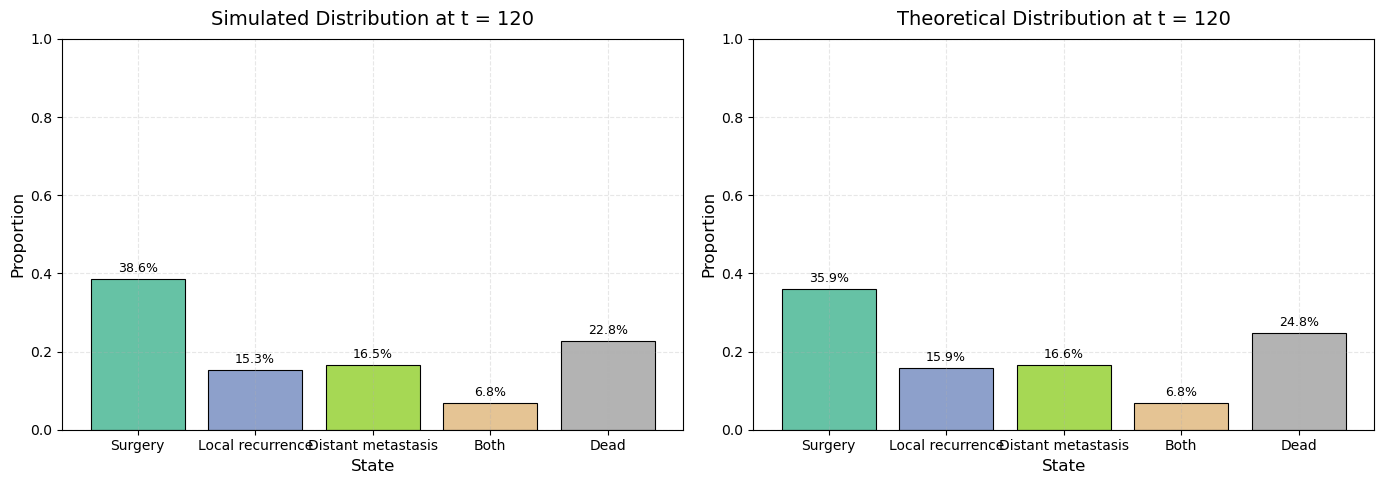

In [91]:
#distributions over states at t = 120
dist_120 = states_over_time[:, 120]
state_props_120 = np.bincount(dist_120, minlength=n_states) / n_women
colors = plt.cm.Set2(np.linspace(0, 1, n_states))

dist_120_ex = pi[120]  # Theoretical distribution at t=120 from matrix power
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simulated
bars_sim = axes[0].bar(
    range(n_states),
    state_props_120,
    tick_label=state_labels,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)
axes[0].set_title("Simulated Distribution at t = 120", pad=10)
axes[0].set_xlabel("State")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)
axes[0].grid(axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars_sim, state_props_120):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.1%}",
                 ha="center", va="bottom", fontsize=9)

# Theoretical
bars_th = axes[1].bar(
    range(n_states),
    dist_120_ex,
    tick_label=state_labels,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)
axes[1].set_title("Theoretical Distribution at t = 120", pad=10)
axes[1].set_xlabel("State")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)
axes[1].grid(axis="y", linestyle="--", alpha=0.3)
for bar, v in zip(bars_th, dist_120_ex):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.1%}",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [113]:
#chi squared test for distribution at t=120
count_expected = state_props_120 * n_women
count_observed = np.bincount(dist_120, minlength=n_states)

# Recompute test as 1D observed vs 1D expected counts
count_expected = dist_120_ex * n_women
count_expected *= count_observed.sum() / count_expected.sum()  # ensure equal totals

chi2, p = scipy.stats.chisquare(f_obs=count_observed, f_exp=count_expected)
print(f"Chi-squared statistic: {chi2:.4f}, p-value: {p:.6f}")

Chi-squared statistic: 3.9001, p-value: 0.419689


## Task 3

In [102]:
np.random.seed(42)  # for reproducibility

Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910],
], dtype=float)

n_states = Ps.shape[0]
ones = np.ones(n_states)
ps = P[:-1, -1]  # transient -> dead probs

pi_s = np.array([1.0, 0.0, 0.0, 0.0])  # start in state 0
Mean_theory = float(pi_s @ np.linalg.inv(np.eye(n_states) - Ps) @ ones)

# Simulated time to absorption
time_until_dead = np.argmax(states_over_time == DEAD, axis=1)
mean_time_sim = time_until_dead.mean()

print(f"Mean time until absorption (Dead) - Simulated: {mean_time_sim:.2f} months")
print(f"Mean time until absorption (Dead) - Theoretical: {Mean_theory:.2f} months")


# simulated lifetimes
lifetimes = time_until_dead

# choose bins, e.g. 0-50, 50-100, ..., with final bin as tail
bins = np.linspace(0, T, 15+1)  # 0, 50, 100, ..., 300

observed, _ = np.histogram(lifetimes, bins=bins)

# theoretical probabilities for each month
max_t = int(bins[-2])  # last finite bin, here 300

theory_pmf = np.array([
    pi_s @ np.linalg.matrix_power(Ps, t) @ ps
    for t in range(max_t)
])

# theoretical bin probabilities
expected_probs = []

for i in range(len(bins) - 2):
    a = int(bins[i])
    b = int(bins[i + 1])
    expected_probs.append(theory_pmf[a:b].sum())

# tail probability from 300 to infinity
tail_start = int(bins[-2])
tail_prob = pi_s @ np.linalg.matrix_power(Ps, tail_start) @ ones
expected_probs.append(tail_prob)

expected_probs = np.array(expected_probs)

# convert probabilities to expected counts
expected = expected_probs * len(lifetimes)

# chi-square test
chi2_stat, p_value = scipy.stats.chisquare(f_obs=observed, f_exp=expected)

print("Observed:", observed)
print("Expected:", expected.round(2))
print(f"Chi-square statistic: {chi2_stat:.3f}")
print(f"p-value: {p_value:.4f}")

Mean time until absorption (Dead) - Simulated: 268.38 months
Mean time until absorption (Dead) - Theoretical: 262.37 months
Observed: [143 217 200 161 101  76  50  24  13   7   4   1   1   0   2]
Expected: [161.83 220.47 199.53 148.91 103.49  66.14  41.11  24.99  14.49   8.43
   4.72   2.65   1.48   0.8    0.95]
Chi-square statistic: 10.379
p-value: 0.7340


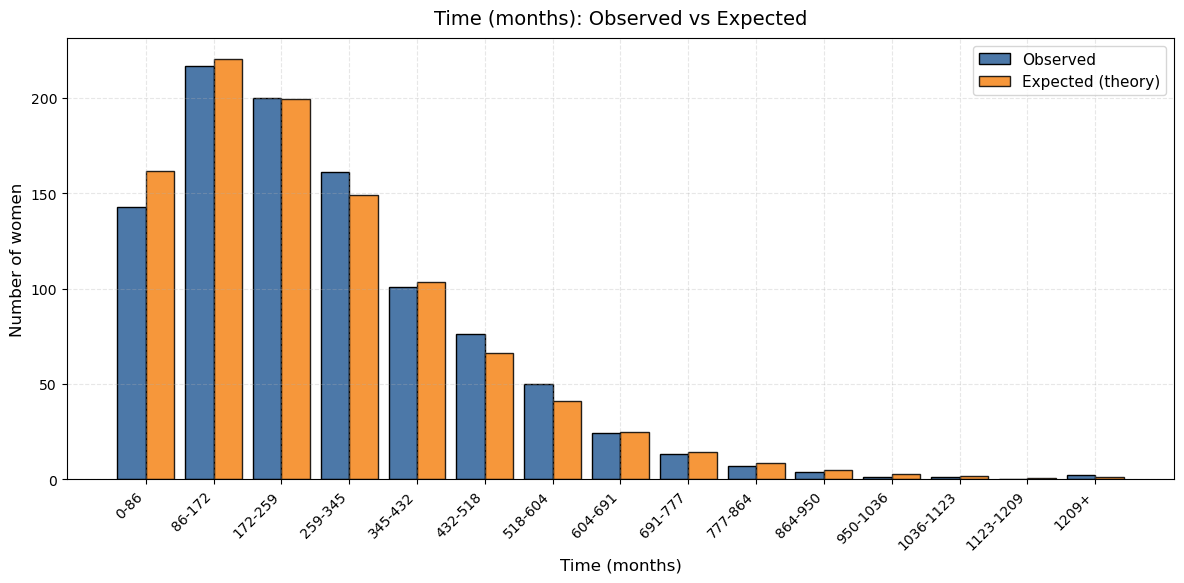

In [118]:
bin_labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-2)] + [f"{int(bins[-2])}+"]
x = np.arange(len(bin_labels))
width = 0.42

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width/2, observed, width=width, color="#4C78A8", edgecolor="black", label="Observed")
ax.bar(x + width/2, expected, width=width, color="#F58518", edgecolor="black", alpha=0.85, label="Expected (theory)")

ax.set_title("Time (months): Observed vs Expected", pad=10)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Number of women")
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

## Task 4

In [133]:
np.random.seed(42)  # for reproducibility
target_n = 1000
dead_state = P.shape[0] - 1
recurrence_states = {1, 2, 3}

rng = np.random.default_rng(42)
accepted_lifetimes = []
attempts = 0

while len(accepted_lifetimes) < target_n:
    attempts += 1
    state = X0
    t = 0
    had_recurrence_12 = False

    # Simulate first 12 months
    while t <= 12 and state != dead_state:
        state = rng.choice(P.shape[0], p=P[state])
        t += 1
        if state in recurrence_states:
            had_recurrence_12 = True

    survived_12 = (state != dead_state)
    if not (survived_12 and had_recurrence_12):
        continue  # reject

    # Continue until death
    while state != dead_state:
        state = rng.choice(P.shape[0], p=P[state])
        t += 1

    accepted_lifetimes.append(t)

lifetimes_eligible = np.array(accepted_lifetimes)
mean_lifetime_eligible = lifetimes_eligible.mean()

print(f"Accepted simulations: {len(lifetimes_eligible)} / {attempts}")
print(f"Acceptance rate: {len(lifetimes_eligible)/attempts:.2%}")
print(f"Estimated expected lifetime for eligible women: {mean_lifetime_eligible:.2f} months")

Accepted simulations: 1000 / 11028
Acceptance rate: 9.07%
Estimated expected lifetime for eligible women: 182.98 months


## Task 5

In [132]:
np.random.seed(42)  

n_rep = 100  
m_women = 200             
threshold_months = 350    

Q = P[:-1, :-1]
alpha = np.zeros(Q.shape[0])
alpha[X0] = 1.0
mu_C = float(alpha @ np.linalg.inv(np.eye(Q.shape[0]) - Q) @ np.ones(Q.shape[0]))


def simulate_lifetimes_batch(P, m, X0, dead_state):
    lifetimes = np.zeros(m, dtype=int)
    for i in range(m):
        state = X0
        t = 0
        while state != dead_state:
            state = np.random.choice(P.shape[0], p=P[state])
            t += 1
        lifetimes[i] = t
    return lifetimes


Y = np.zeros(n_rep)  
C = np.zeros(n_rep)  

for r in range(n_rep):
    lifetimes_r = simulate_lifetimes_batch(P, m_women, X0, DEAD)
    Y[r] = np.mean(lifetimes_r <= threshold_months)
    C[r] = np.mean(lifetimes_r)

# Estimate optimal beta from the simulation output
beta_hat = np.cov(Y, C, ddof=1)[0, 1] / np.var(C, ddof=1)

# Control variate adjusted estimator per replication
Y_cv = Y - beta_hat * (C - mu_C)

# Monte Carlo estimates and variance comparison
p_crude = float(np.mean(Y))
p_cv = float(np.mean(Y_cv))

var_crude = float(np.var(Y, ddof=1))
var_cv = float(np.var(Y_cv, ddof=1))
reduction_factor = var_crude / var_cv
reduction_pct = 100.0 * (1.0 - var_cv / var_crude)

print(f"Estimated fraction dead within {threshold_months} months (crude): {p_crude:.4f}")
print(f"Estimated fraction dead within {threshold_months} months (control variate): {p_cv:.4f}")
print(f"Estimated beta: {beta_hat:.4f}")
print(f"Var(crude estimator): {var_crude:.6e}")
print(f"Var(control-variate estimator): {var_cv:.6e}")
print(f"Variance reduction factor: {reduction_factor:.2f}x")
print(f"Variance reduction: {reduction_pct:.2f}%")


Estimated fraction dead within 350 months (crude): 0.7375
Estimated fraction dead within 350 months (control variate): 0.7371
Estimated beta: -0.0021
Var(crude estimator): 1.301260e-03
Var(control-variate estimator): 3.090993e-04
Variance reduction factor: 4.21x
Variance reduction: 76.25%


# Part 2

## Task 7

In [134]:
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001],
              [0, -0.014, 0.005, 0.004, 0.005],
              [0, 0, -0.008, 0.003, 0.005],
              [0, 0, 0, -0.009, 0.009],
              [0, 0, 0, 0, 0]])
n_women = 1000
X0 = 0
n_states = Q.shape[0]
DEAD = n_states - 1  

def simulate_ctmc(Q, n_women, X0=0):
    lifetimes = np.zeros(n_women)
    distant_after_30_5 = np.zeros(n_women, dtype=bool)

    for w in range(n_women):
        state = X0
        time = 0.0

        while state != DEAD:
            rate = -Q[state, state]

            waiting_time = np.random.exponential(scale=1 / rate)
            time += waiting_time

            probs = Q[state].copy()
            probs[state] = 0
            probs = probs / rate

            next_state = np.random.choice(Q.shape[0], p=probs)

            if time > 30.5 and next_state in [2, 3]:
                distant_after_30_5[w] = True

            state = next_state

        lifetimes[w] = time

    return lifetimes, distant_after_30_5

lifetimes, distant_after_30_5 = simulate_ctmc(Q, n_women, X0)

In [136]:
distant_after_30_5_proportion = distant_after_30_5.mean() * 100
print(f"Proportion of women who develop distant metastasis after 30.5 months: {distant_after_30_5_proportion:.2f}%")

Proportion of women who develop distant metastasis after 30.5 months: 59.90%


In [135]:
from scipy.stats import t, chi2

mean_lifetime = np.mean(lifetimes)
sd_lifetime = np.std(lifetimes, ddof=1)

alpha = 0.05
n = len(lifetimes)

# CI for mean
se = sd_lifetime / np.sqrt(n)
t_crit = t.ppf(1 - alpha / 2, df=n - 1)

mean_ci = (
    mean_lifetime - t_crit * se,
    mean_lifetime + t_crit * se
)

# CI for standard deviation
sd_ci = (
    np.sqrt((n - 1) * sd_lifetime**2 / chi2.ppf(1 - alpha / 2, df=n - 1)),
    np.sqrt((n - 1) * sd_lifetime**2 / chi2.ppf(alpha / 2, df=n - 1))
)

print(f"Mean lifetime: {mean_lifetime:.2f} months")
print(f"95% CI for mean: ({mean_ci[0]:.2f}, {mean_ci[1]:.2f})")

print(f"Standard deviation: {sd_lifetime:.2f} months")
print(f"95% CI for SD: ({sd_ci[0]:.2f}, {sd_ci[1]:.2f})")

Mean lifetime: 256.37 months
95% CI for mean: (244.31, 268.43)
Standard deviation: 194.38 months
95% CI for SD: (186.22, 203.29)


## Task 8

In [140]:
Qs = Q[:-1, :-1]
pi0 = np.array([1, 0, 0, 0])  # start in state 0
ones = np.ones(Qs.shape[0])
def theoretical_cdf(t):
    t = np.asarray(t)

    if t.ndim == 0:
        return 1 - pi0 @ scipy.linalg.expm(Qs * t) @ ones

    return np.array([
        1 - pi0 @ scipy.linalg.expm(Qs * ti) @ ones
        for ti in t
    ])

ks_stat, p_value = scipy.stats.kstest(
    lifetimes,
    theoretical_cdf
)

print(f"KS statistic = {ks_stat:.4f}")
print(f"p-value = {p_value:.4f}")

KS statistic = 0.0239
p-value = 0.6110


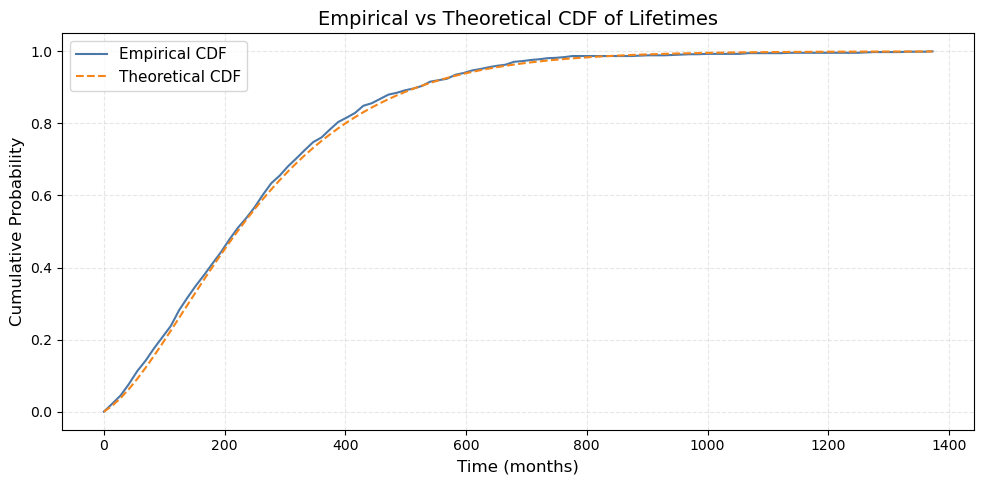

In [147]:
#plotting the empirical CDF vs theoretical CDF
t_values = np.linspace(0, lifetimes.max(), 100)
theory_cdf_values = theoretical_cdf(t_values)  
empirical_cdf_values = np.array([
    np.mean(lifetimes <= t) for t in t_values
])

plt.figure()
plt.plot(t_values, empirical_cdf_values, label="Empirical CDF", color="#4C78A8")
plt.plot(t_values, theory_cdf_values, label="Theoretical CDF", color="#F58518", linestyle="--")
plt.title("Empirical vs Theoretical CDF of Lifetimes")
plt.xlabel("Time (months)")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.tight_layout()
plt.show()

## Task 9

In [152]:
np.random.seed(42)  # for reproducibility
Q_treat = np.array([
    [0, 0.0025, 0.00125, 0,      0.001],
    [0, 0,      0,       0.002,  0.005],
    [0, 0,      0,       0.003,  0.005],
    [0, 0,      0,       0,      0.009],
    [0, 0,      0,       0,      0]
], dtype=float)

# Fill diagonal entries
for i in range(Q_treat.shape[0]):
    Q_treat[i, i] = -np.sum(Q_treat[i, :])

Q_treat

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.     ,  0.002  ,  0.005  ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     , -0.     ]])

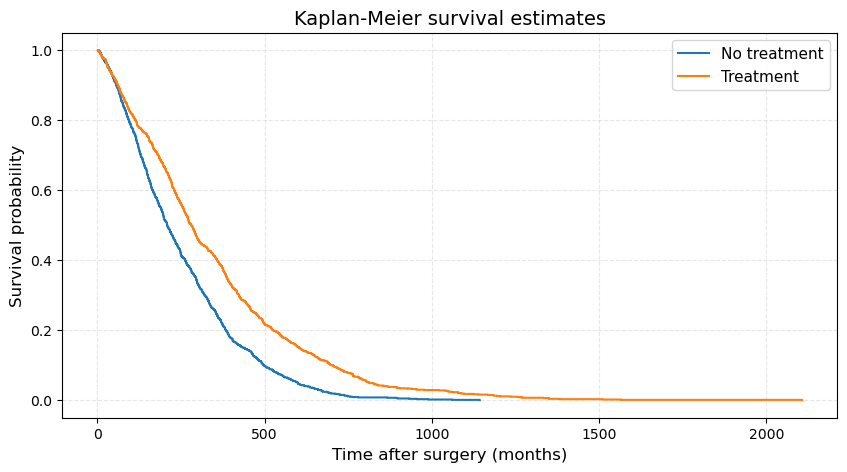

In [153]:
np.random.seed(42)  # for reproducibility
lifetimes_treat, _ = simulate_ctmc(Q_treat, n_women=1000, X0=0)
lifetimes_no_treat, _ = simulate_ctmc(Q, n_women=1000, X0=0)


def survival_curve(lifetimes):
    t_grid = np.sort(lifetimes)
    S = np.array([np.mean(lifetimes > t) for t in t_grid])
    return t_grid, S

t_no, S_no = survival_curve(lifetimes_no_treat)
t_tr, S_tr = survival_curve(lifetimes_treat)

plt.step(t_no, S_no, where="post", label="No treatment")
plt.step(t_tr, S_tr, where="post", label="Treatment")
plt.xlabel("Time after surgery (months)")
plt.ylabel("Survival probability")
plt.title("Kaplan-Meier survival estimates")
plt.legend()
plt.show()

# Part 3

## Task 12

In [154]:
np.random.seed(42)  # for reproducibility
n_women = 1000 
X0 = 0
n_states = Q_treat.shape[0]
DEAD = n_states - 1

Yi = np.zeros(n_women)

Yi = []

obs_step = 48  

for w in range(n_women):
    state = X0                  
    t = 0.0
    next_obs = 0.0
    y_w = []

    while True:
        if state == DEAD:
            y_w.append(DEAD)  
            break

        rate = -Q_treat[state, state]
        jump_time = t + np.random.exponential(scale=1 / rate)

        # Record observed state at t = 0, 48, 96, ... until next jump
        while next_obs < jump_time:
            y_w.append(state) 
            next_obs += obs_step

        # Do jump
        probs = Q_treat[state].copy()
        probs[state] = 0.0
        probs = probs / rate
        state = np.random.choice(Q_treat.shape[0], p=probs)
        t = jump_time

    Yi.append(np.array(y_w, dtype=int))


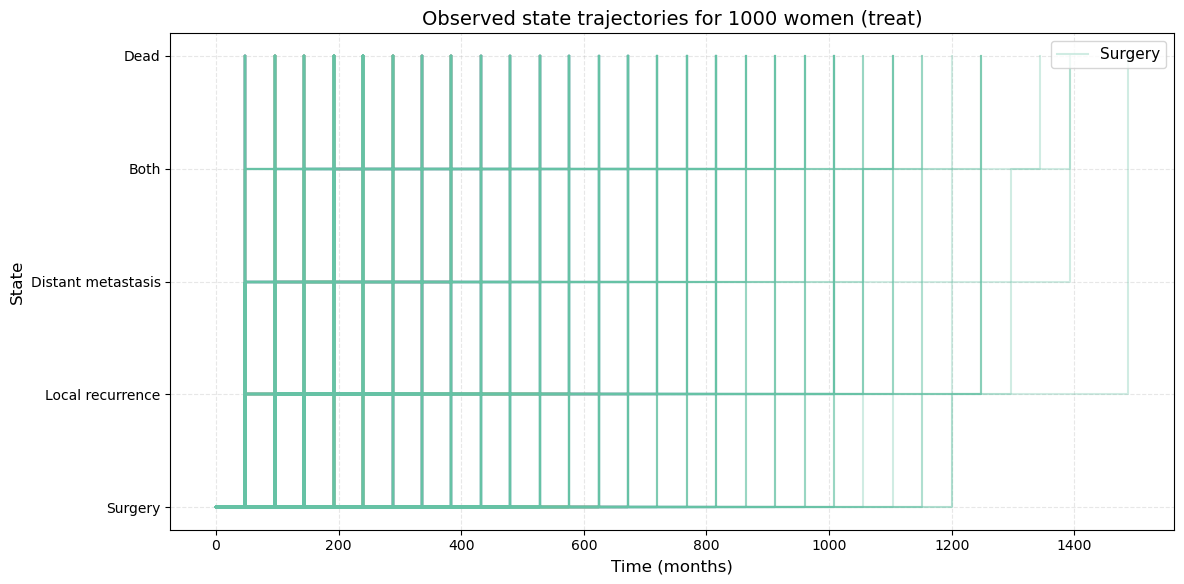

In [158]:
# Build an aligned observation matrix (pad with DEAD after individual trajectories end)
n_women_obs = len(Yi)
max_obs = max(len(path) for path in Yi)

Y_mat = np.full((n_women_obs, max_obs), DEAD, dtype=int)
for i, path in enumerate(Yi):
    Y_mat[i, :len(path)] = path

obs_times = np.arange(max_obs) * obs_step
labels = state_labels if ("state_labels" in globals() and len(state_labels) == n_states) else [f"State {s}" for s in range(n_states)]

# Proportion in each state at each observation time
props = np.array([(Y_mat == s).mean(axis=0) for s in range(n_states)])

plt.figure(figsize=(10, 5))
for s in range(n_states):
    plt.plot(obs_times, props[s], marker="o", linewidth=1.8, label=labels[s])

plt.title("Observed state proportions over time (every 48 months)")
plt.xlabel("Time (months)")
plt.ylabel("Proportion")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [163]:
np.random.seed(42)

obs_paths = Yi
obs_step = 48.0
n_states = Q_treat.shape[0] 
DEAD = n_states - 1



allowed = np.array([
        [0, 1, 1, 0, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 1, 1],
        [0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0],
    ], dtype=int)

np.fill_diagonal(allowed, 0)


def make_generator_from_offdiag(Q_offdiag):
    Q_full = Q_offdiag.copy()
    np.fill_diagonal(Q_full, 0.0)
    for i in range(Q_full.shape[0]):
        Q_full[i, i] = -Q_full[i].sum()
    Q_full[DEAD, :] = 0.0
    return Q_full


def simulate_segment_stats(Qk, y0, y1, delta, max_bridge_attempts=2000):

    n = Qk.shape[0]

    for _ in range(max_bridge_attempts):
        N_seg = np.zeros((n, n), dtype=float)
        S_seg = np.zeros(n, dtype=float)

        state = int(y0)
        t = 0.0

        while t < delta:
            if state == DEAD:
                S_seg[DEAD] += (delta - t)
                t = delta
                break

            rate = -Qk[state, state]
            if rate <= 0:
                break

            wait = np.random.exponential(scale=1.0 / rate)

            if t + wait >= delta:
                S_seg[state] += (delta - t)
                t = delta
                break

            S_seg[state] += wait
            probs = Qk[state].copy()
            probs[state] = 0.0
            probs = probs / rate

            next_state = np.random.choice(n, p=probs)
            N_seg[state, next_state] += 1.0

            t += wait
            state = int(next_state)

        if state == int(y1):
            return True, N_seg, S_seg

    return False, np.zeros((n, n), dtype=float), np.zeros(n, dtype=float)


Qk_offdiag = 0.002 * allowed.astype(float)
Qk = make_generator_from_offdiag(Qk_offdiag)

max_iter = 25
tol = 1e-3
converged = False

for k in range(max_iter):
    N_k = np.zeros((n_states, n_states), dtype=float)
    S_k = np.zeros(n_states, dtype=float)

    total_bridges = 0
    failed_bridges = 0

    # E-step (Monte Carlo): bridge each interval of each observed woman
    for path in obs_paths:
        y = np.asarray(path, dtype=int)

        for idx in range(len(y) - 1):
            y0 = int(y[idx])
            y1 = int(y[idx + 1])

            if y0 == DEAD:
                break

            ok, N_seg, S_seg = simulate_segment_stats(Qk, y0, y1, obs_step)
            total_bridges += 1

            if ok:
                N_k += N_seg
                S_k += S_seg
            else:
                failed_bridges += 1

    # M-step: q_ij = N_ij / S_i for i != j, q_ii = -sum_{j!=i} q_ij
    Q_next = np.zeros_like(Qk)

    for i in range(n_states):
        if i == DEAD:
            continue

        if S_k[i] > 0:
            for j in range(n_states):
                if i != j and allowed[i, j] == 1:
                    Q_next[i, j] = N_k[i, j] / S_k[i]
        else:
            # Keep previous row if no exposure time for state i
            for j in range(n_states):
                if i != j and allowed[i, j] == 1:
                    Q_next[i, j] = Qk[i, j]

        Q_next[i, i] = -Q_next[i].sum()

    Q_next[DEAD, :] = 0.0

    diff_inf = np.max(np.abs(Q_next - Qk))
    accept_rate = (total_bridges - failed_bridges) / total_bridges if total_bridges > 0 else 0.0

    print(
        f"Iter {k+1:02d}: ||Q_next - Q||_inf = {diff_inf:.6f}, "
        f"bridge accept rate = {accept_rate:.2%}, failed bridges = {failed_bridges}"
    )

    Qk = Q_next

    if diff_inf < tol:
        converged = True
        break

print("\nConverged:" if converged else "\nStopped at max_iter.", converged)
print("Estimated Q:")
print(np.round(Qk, 6))

if "Q_treat" in globals():
    print("\nTrue Q_treat (for comparison):")
    print(np.round(Q_treat, 6))
    print("\nAbsolute error |Q_hat - Q_treat|:")
    print(np.round(np.abs(Qk - Q_treat), 6))


Iter 01: ||Q_next - Q||_inf = 0.006307, bridge accept rate = 100.00%, failed bridges = 0
Iter 02: ||Q_next - Q||_inf = 0.000466, bridge accept rate = 100.00%, failed bridges = 0

Converged: True
Estimated Q:
[[-0.004735  0.002296  0.001193  0.        0.001245]
 [ 0.       -0.006784  0.        0.002098  0.004686]
 [ 0.        0.       -0.007582  0.002678  0.004904]
 [ 0.        0.        0.       -0.008773  0.008773]
 [ 0.        0.        0.        0.        0.      ]]

True Q_treat (for comparison):
[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.      -0.     ]]

Absolute error |Q_hat - Q_treat|:
[[1.50e-05 2.04e-04 5.70e-05 0.00e+00 2.45e-04]
 [0.00e+00 2.16e-04 0.00e+00 9.80e-05 3.14e-04]
 [0.00e+00 0.00e+00 4.18e-04 3.22e-04 9.60e-05]
 [0.00e+00 0.00e+00 0.00e+00 2.27e-04 2.27e-04]
 [0.00e+00 0.00e+00 0.00e+